## **Data Cleaning**

### Import Liblary

In [1]:
# Import liblary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [2]:
# Load Dataset
df = pd.read_csv('/content/marketing_campaign_raw.csv')

In [3]:
# Menampilkan 5 data teratas
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### Initial Inspection

In [4]:
df.shape

(11162, 17)

In [5]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [11]:
df['deposit'].value_counts()

,count
deposit,
no,5873
yes,5289


In [12]:
df['deposit'] = df['deposit'].map({
    'yes':1,
    'no':0
})

In [13]:
df['default'].value_counts()

,count
default,
no,10994
yes,168


In [14]:
df['default'] = df['default'].map({
    'yes':1,
    'no':0
})

In [15]:
df['housing'] = df['housing'].map({
    'yes':1,
    'no':0
})

In [16]:
df['loan'] = df['loan'].map({
    'yes':1,
    'no':0
})

In [17]:
df['pdays'].value_counts().head()

,count
pdays,
-1,8324
92,106
182,89
91,84
181,81


In [18]:
df['previous_contact'] = np.where(
    df['pdays'] == -1,
    'No Previous Contact',
    'Previously Contacted'
)

In [19]:
df['pdays_clean'] = np.where(
    df['pdays'] == -1,
    np.nan,
    df['pdays']
)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               11162 non-null  int64  
 1   job               11162 non-null  object 
 2   marital           11162 non-null  object 
 3   education         11162 non-null  object 
 4   default           11162 non-null  int64  
 5   balance           11162 non-null  int64  
 6   housing           11162 non-null  int64  
 7   loan              11162 non-null  int64  
 8   contact           11162 non-null  object 
 9   day               11162 non-null  int64  
 10  month             11162 non-null  object 
 11  duration          11162 non-null  int64  
 12  campaign          11162 non-null  int64  
 13  pdays             11162 non-null  int64  
 14  previous          11162 non-null  int64  
 15  poutcome          11162 non-null  object 
 16  deposit           11162 non-null  int64 

In [21]:
df.describe()

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,deposit,pdays_clean
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,2838.000000
mean,41.231948,0.015051,1528.538524,0.473123,0.130801,15.658036,371.993818,2.508421,51.330407,0.832557,0.473840,204.818182
std,11.913369,0.121761,3225.413326,0.499299,0.337198,8.420740,347.128386,2.722077,108.758282,2.292007,0.499338,122.196901
min,18.000000,0.000000,-6847.000000,0.000000,0.000000,1.000000,2.000000,1.000000,-1.000000,0.000000,0.000000,1.000000
25%,32.000000,0.000000,122.000000,0.000000,0.000000,8.000000,138.000000,1.000000,-1.000000,0.000000,0.000000,98.000000
50%,39.000000,0.000000,550.000000,0.000000,0.000000,15.000000,255.000000,2.000000,-1.000000,0.000000,0.000000,182.000000
75%,49.000000,0.000000,1708.000000,1.000000,0.000000,22.000000,496.000000,3.000000,20.750000,1.000000,1.000000,286.000000
max,95.000000,1.000000,81204.000000,1.000000,1.000000,31.000000,3881.000000,63.000000,854.000000,58.000000,1.000000,854.000000


In [22]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [23]:
df.duplicated().sum()

np.int64(0)

### Outlier Chek

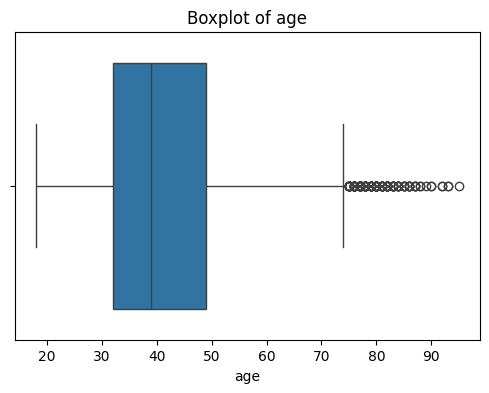

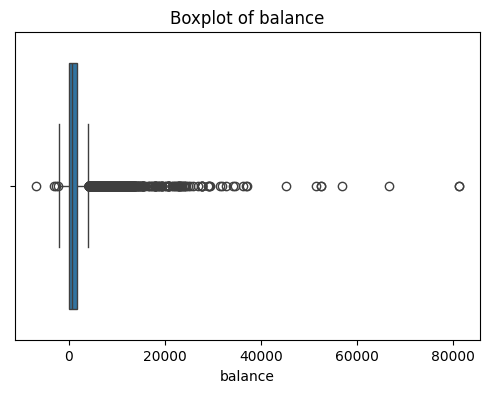

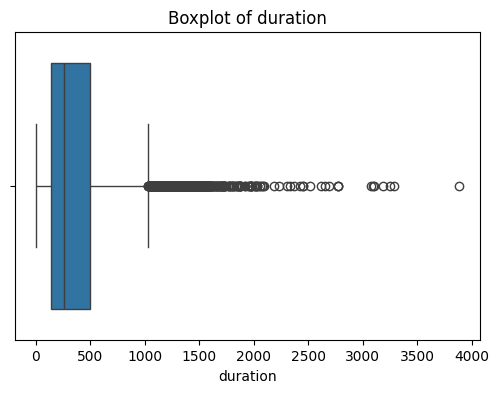

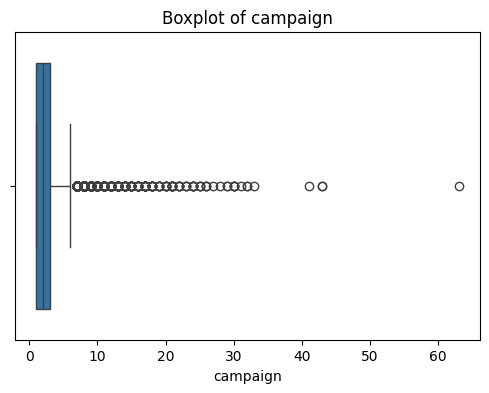

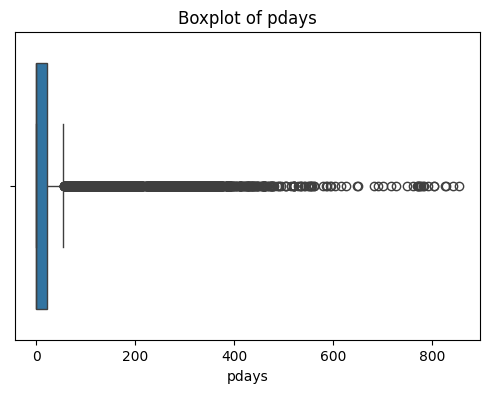

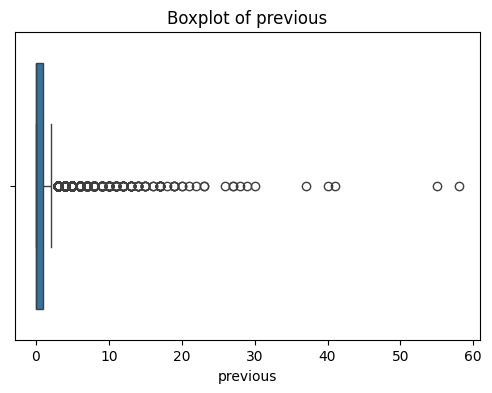

In [24]:
outlier_cols = [
    'age',
    'balance',
    'duration',
    'campaign',
    'pdays',
    'previous'
]

for col in outlier_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### Save Dataset

In [25]:
df.to_csv(
    'cleaned_data.csv',
    index=False
)